<a href="https://colab.research.google.com/github/hakim3189/MachineLearning/blob/main/%5BClustering%5D_Submission_Akhir_BMLP_M%20Rheza%20Iwanul%20Hakim%20ver2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Penting**
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Hapus simbol pagar (#) jika Anda menerapkan kriteria tambahan
- Biarkan simbol pagar (#) jika Anda tidak menerapkan kriteria tambahan

# **INFORMASI DATASET**
## Latar Belakang

Dalam dunia bisnis ritel, pemahaman terhadap perilaku pelanggan menjadi salah satu faktor krusial dalam menentukan strategi pemasaran, peningkatan layanan, serta pengambilan keputusan berbasis data. Salah satu pendekatan yang umum digunakan untuk memahami perilaku pelanggan adalah melalui segmentasi, yaitu proses pengelompokan pelanggan ke dalam beberapa segmen atau kelompok berdasarkan karakteristik tertentu.

Dengan menerapkan metode **unsupervised learning**, khususnya **clustering**, proyek ini bertujuan untuk membentuk segmentasi pelanggan yang merepresentasikan pola-pola pembelian yang serupa. Hasil segmentasi ini diharapkan dapat memberikan insight yang bernilai bagi pihak manajemen, khususnya dalam menyusun strategi promosi yang lebih tepat sasaran, mengembangkan program loyalitas, serta mengoptimalkan layanan pelanggan.

# **1. Import Library**
Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning. Semua library yang dibutuhkan harus **import** di **cell** ini, jika ada library yang dijalankan di cell lain maka **submission langsung ditolak**

In [1]:
# Import Library

!pip install yellowbrick
from yellowbrick.cluster import KElbowVisualizer
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# **2. Memuat Dataset**
Pada tahap ini, Anda perlu memuat dataset ke dalam notebook lalu mengecek informasi dataset sebelum nantinya dilakukan pembersihan. Hal-hal yang perlu dilakukan pada tahapan ini yaitu:
1. **Memahami Struktur Data**
   - Dataset harus mengambil referensi wajib digunakan (bisa dilihat [Disini](https://drive.google.com/drive/folders/1Zs7VmPZ-jNwsRlMKH65Ea-LApSwx6lKx?usp=drive_link))
   - Melakukan loading dataset ke dalam notebook dan menampilkan 5 baris pertama dengan function `head`.
   - Tinjau jumlah baris kolom dan jenis data dalam dataset dengan function `info`.  
   - Menampilkan statistik deskriptif dataset dengan menjalankan `describe`.
   - Pastikan **setiap function tersebut** memiliki **output pada setiap cell** code. Jika tidak **submission langsung ditolak**
   

Gunakan code ini untuk melakukan load data secara otomatis tanpa harus download data tersebut secara manual:
```python
url='https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'
df = pd.read_csv(url)
```

In [2]:
url = 'https://drive.google.com/uc?id=1gnLO9qvEPqv1uBt1928AcsCmdvzqjC5m'  # Updated URL to access the raw CSV file
df = pd.read_csv(url)

In [3]:
# Tampilkan 5 baris pertama dengan function head.
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [4]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

In [5]:
# Menampilkan statistik deskriptif dataset dengan menjalankan describe
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [6]:
# Menampilkan korelasi antar fitur (Opsional Skilled 1)
numerical_df = df.select_dtypes(include=np.number)  # Select only numerical columns
numerical_df.corr()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
TransactionAmount,1.000000,-0.024428,0.004782,-0.007397,-0.026310
CustomerAge,-0.024428,1.000000,-0.009852,0.007876,0.321161
TransactionDuration,0.004782,-0.009852,1.000000,0.030076,0.006859
LoginAttempts,-0.007397,0.007876,0.030076,1.000000,0.009088
AccountBalance,-0.026310,0.321161,0.006859,0.009088,1.000000


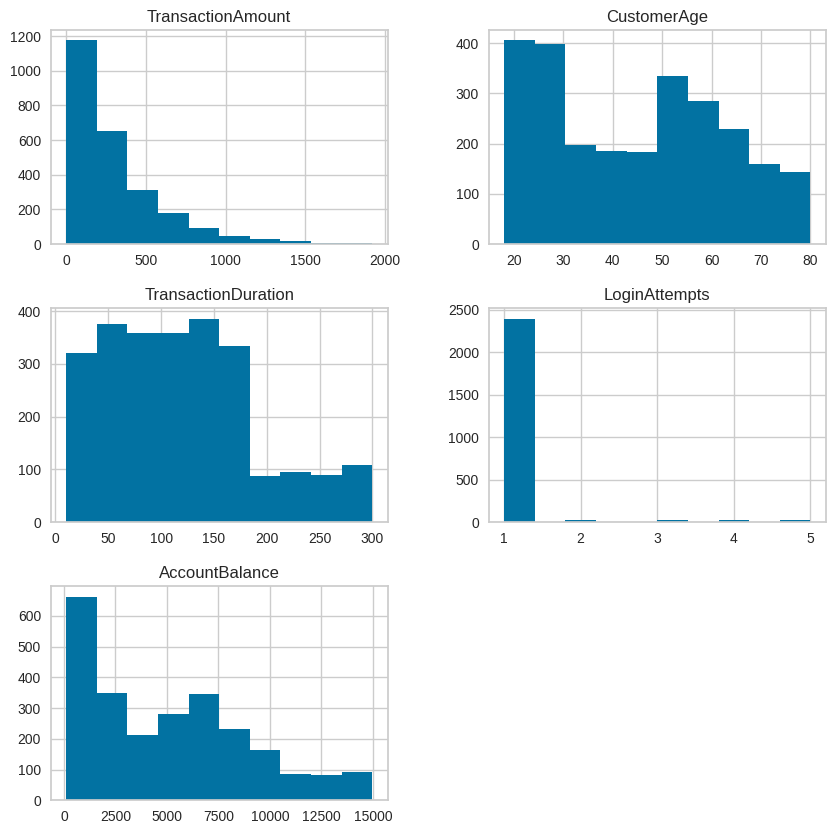

In [7]:
# Menampilkan histogram untuk semua kolom numerik (Opsional Skilled 1)
numerical_df = df.select_dtypes(include=np.number)
numerical_df.hist(figsize=(10, 10))
plt.show()


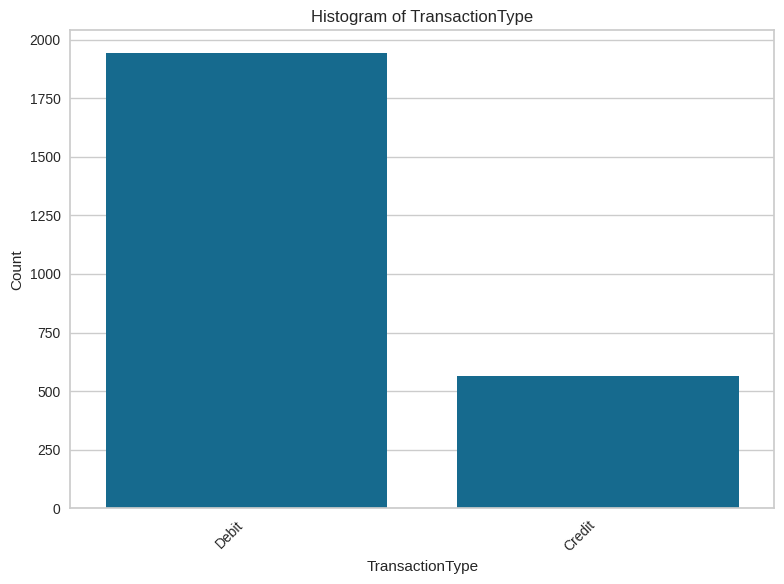

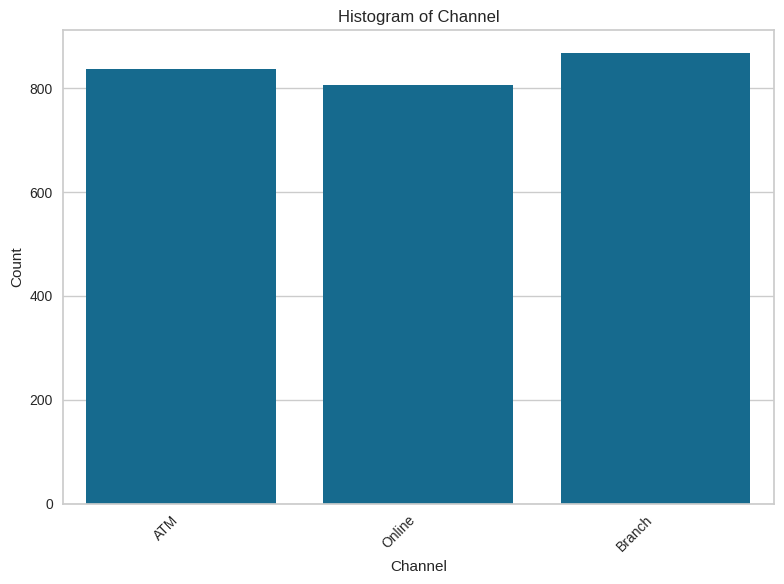

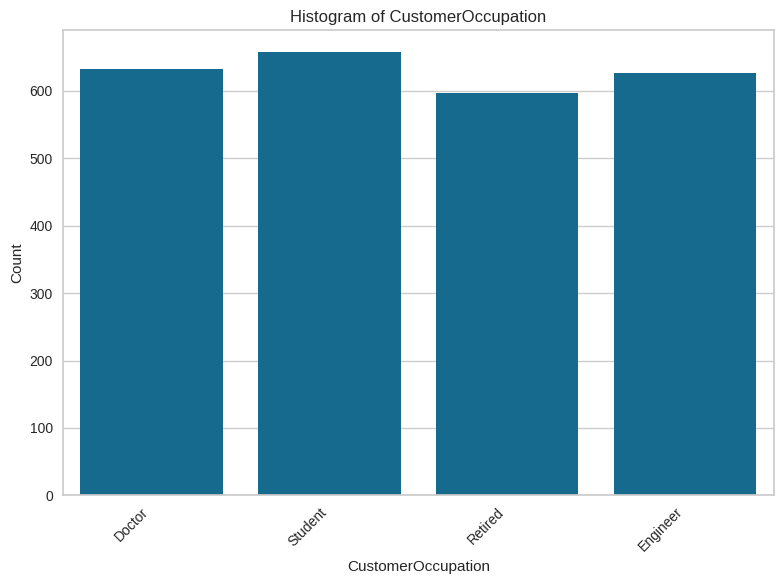

In [8]:
# Loop through each column in the DataFrame
for column in df.columns:
    # Check if the column is of object (categorical) type and has less than 30 unique values
    if df[column].dtype == 'object' and df[column].nunique() < 30:
        plt.figure(figsize=(8, 6))  # Adjust figure size as needed
        sns.countplot(x=column, data=df)
        plt.title(f'Histogram of {column}')
        plt.xlabel(column)
        plt.ylabel('Count')
        plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
        plt.tight_layout() # Adjust layout to prevent labels from overlapping
        plt.show()


In [9]:
# show unique count for every column
for col in df.columns:
    print(f'{col}: {df[col].nunique()} {df[col].dtype}')


TransactionID: 2484 object
AccountID: 495 object
TransactionAmount: 2433 float64
TransactionDate: 2485 object
TransactionType: 2 object
Location: 43 object
DeviceID: 681 object
IP Address: 591 object
MerchantID: 100 object
Channel: 3 object
CustomerAge: 63 float64
CustomerOccupation: 4 object
TransactionDuration: 288 float64
LoginAttempts: 5 float64
AccountBalance: 2483 float64
PreviousTransactionDate: 360 object


(Opsional) Memuat Dataset dan Melakukan Exploratory Data Analysis (EDA) [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

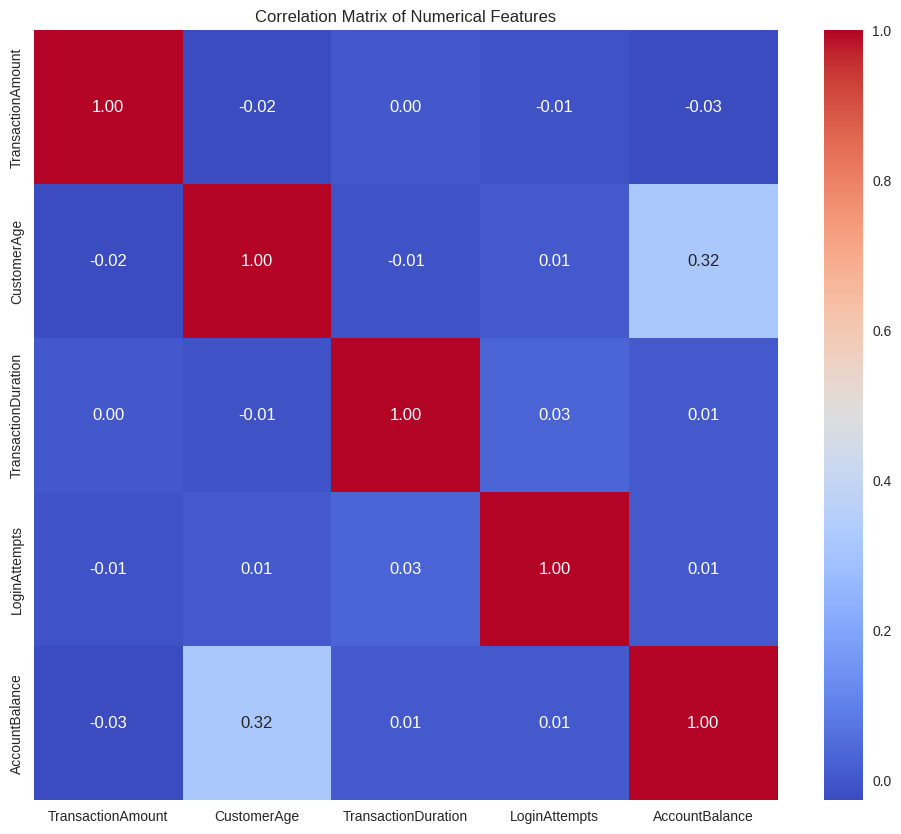

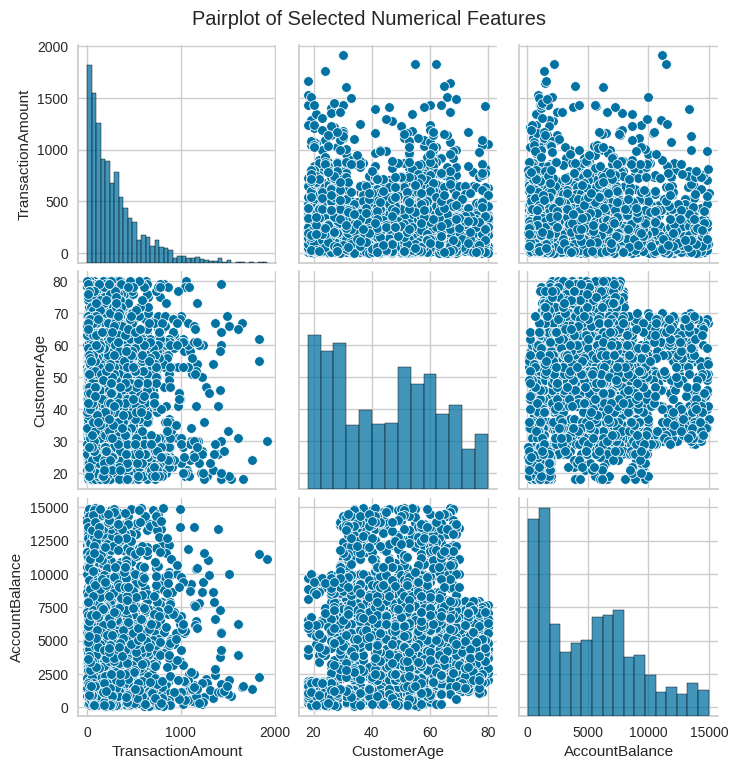

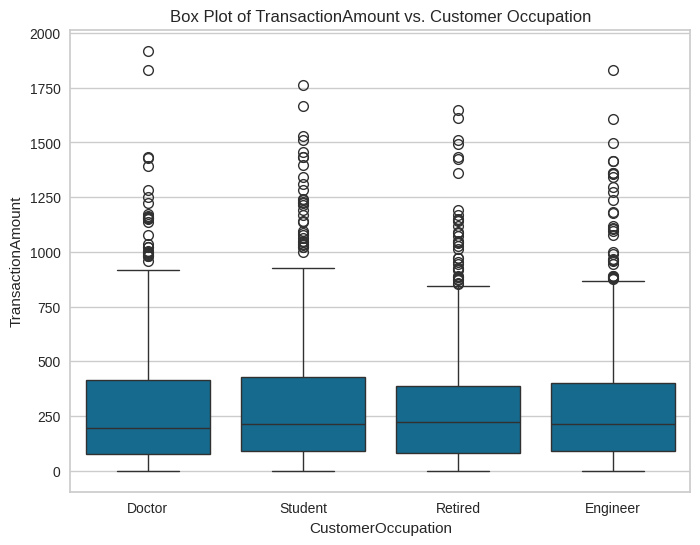

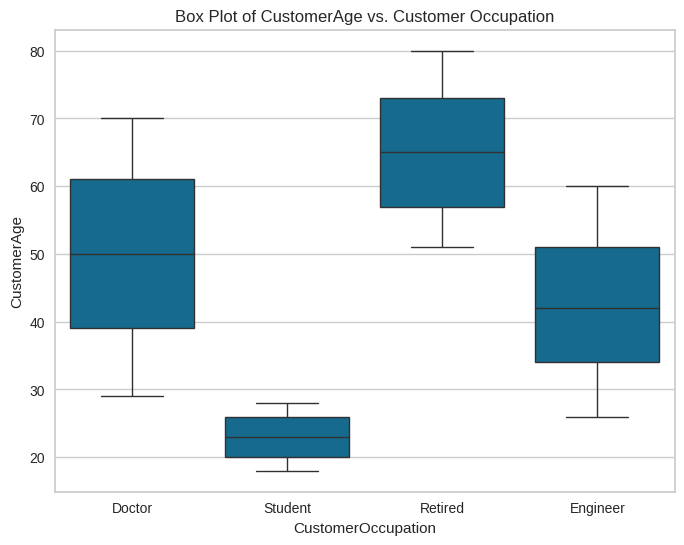

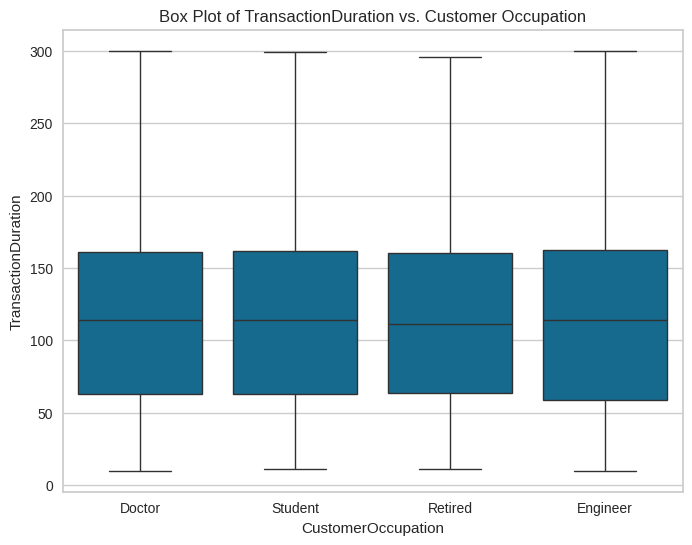

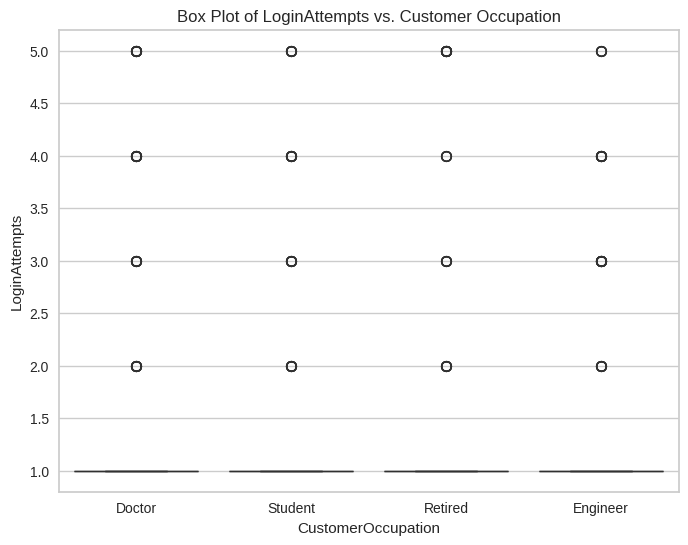

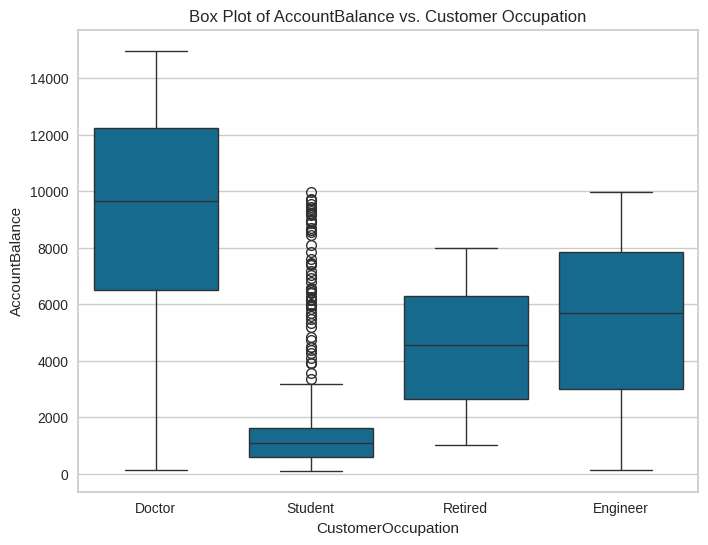

In [10]:
# Visualisasi yang lebih informatif (Opsional Advanced 1)

# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(numerical_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

# Pairplot for selected numerical features
selected_features = ['TransactionAmount', 'CustomerAge', 'AccountBalance']
sns.pairplot(df[selected_features])
plt.suptitle('Pairplot of Selected Numerical Features', y=1.02) # Adjust title position
plt.show()

# Box plots for numerical features vs. a categorical feature (e.g., 'Customer Occupation')
for col in numerical_df.columns:
    plt.figure(figsize=(8, 6))
    sns.boxplot(x='CustomerOccupation', y=col, data=df)
    plt.title(f'Box Plot of {col} vs. Customer Occupation')
    plt.show()


# **3. Pembersihan dan Pra Pemrosesan Data**

Pada tahap ini, Anda akan melakukan **Pembersihan Dataset** untuk menjadikan dataset mudah diintepretasi dan bisa dilatih. Hal-hal yang wajib kamu lakukan yaitu:

1. **Mengecek dataset** menggunakan isnull().sum() dan duplicated().sum().
2. Melakukan feature scaling menggunakan `MinMaxScaler()` atau `StandardScalar()` untuk fitur numerik.
3. Melakukan feature encoding menggunakan `pd.get_dummies()` atau `LabelEncoder()` untuk fitur kategorikal.
4. Melakukan drop pada kolom id.
5. **Ketentuan Cell Code**
   - Pastikan **setiap pemeriksaan tersebut** memiliki **output pada cell-nya**. Jika tidak **submission langsung ditolak**


In [11]:
# Mengecek dataset menggunakan isnull().sum()
df.isnull().sum()

,0
TransactionID,29
AccountID,21
TransactionAmount,26
TransactionDate,28
TransactionType,30
Location,30
DeviceID,30
IP Address,20
MerchantID,23
Channel,27


In [12]:
# Mengecek dataset menggunakan duplicated().sum()
df.duplicated().sum()

np.int64(21)

In [13]:
# Melakukan feature scaling menggunakan MinMaxScaler() atau StandardScalar() untuk fitur numerik.

# Select numerical features
numerical_features = df.select_dtypes(include=np.number).columns

# Initialize the scaler (MinMaxScaler)
scaler = MinMaxScaler()

# Apply scaling to numerical features
df[numerical_features] = scaler.fit_transform(df[numerical_features])

print("Numerical features after scaling:")
print(df[numerical_features].head())

Numerical features after scaling:
   TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  \
0           0.007207     0.838710             0.244828            0.0   
1           0.195940     0.806452             0.451724            0.0   
2           0.065680     0.016129             0.158621            0.0   
3           0.096016     0.129032             0.051724            0.0   
4           0.006874          NaN             0.648276            0.0   

   AccountBalance  
0        0.336832  
1        0.918055  
2        0.068637  
3        0.569198  
4        0.492591  


In [14]:
# Melakukan drop pada kolom yang memiliki keterangan id dan IP Address
df = df.drop(['TransactionID','AccountID','DeviceID','IP Address','MerchantID'], axis=1)

print("DataFrame after dropping 'CustomerID' column:")
print(df.head())

DataFrame after dropping 'CustomerID' column:
   TransactionAmount      TransactionDate TransactionType   Location Channel  \
0           0.007207  2023-04-11 16:29:14           Debit  San Diego     ATM   
1           0.195940  2023-06-27 16:44:19           Debit    Houston     ATM   
2           0.065680  2023-07-10 18:16:08           Debit       Mesa  Online   
3           0.096016  2023-05-05 16:32:11           Debit    Raleigh  Online   
4           0.006874  2023-10-16 17:51:24          Credit    Atlanta  Online   

   CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  \
0     0.838710             Doctor             0.244828            0.0   
1     0.806452             Doctor             0.451724            0.0   
2     0.016129            Student             0.158621            0.0   
3     0.129032            Student             0.051724            0.0   
4          NaN            Student             0.648276            0.0   

   AccountBalance PreviousTransact

In [15]:
# Melakukan feature encoding menggunakan pd.get_dummies() atau LabelEncoder() untuk fitur kategorikal.

# Select categorical features
categorical_features = df.select_dtypes(include='object').columns

# Initialize the LabelEncoder
label_encoder = LabelEncoder()

# Apply Label Encoding to each categorical feature
for col in categorical_features:
    df[col] = label_encoder.fit_transform(df[col])

print("DataFrame after Label Encoding:")
print(df.head())

DataFrame after Label Encoding:
   TransactionAmount  TransactionDate  TransactionType  Location  Channel  \
0           0.007207              680                1        36        0   
1           0.195940             1178                1        15        0   
2           0.065680             1262                1        23        2   
3           0.096016              818                1        33        2   
4           0.006874             1939                0         1        2   

   CustomerAge  CustomerOccupation  TransactionDuration  LoginAttempts  \
0     0.838710                   0             0.244828            0.0   
1     0.806452                   0             0.451724            0.0   
2     0.016129                   3             0.158621            0.0   
3     0.129032                   3             0.051724            0.0   
4          NaN                   3             0.648276            0.0   

   AccountBalance  PreviousTransactionDate  
0        0.3368

(Opsional) Pembersihan dan Pra Pemrosesan Data [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [16]:
# Menangani data yang hilang (bisa menggunakan dropna() atau metode imputasi fillna()).
df.dropna(inplace=True)

In [17]:
# Menghapus data duplikat menggunakan drop_duplicates().
df.drop_duplicates(inplace=True)

In [18]:
# Data setelah dropna dan drop_duplicate
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2398 entries, 0 to 2535
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionAmount        2398 non-null   float64
 1   TransactionDate          2398 non-null   int64  
 2   TransactionType          2398 non-null   int64  
 3   Location                 2398 non-null   int64  
 4   Channel                  2398 non-null   int64  
 5   CustomerAge              2398 non-null   float64
 6   CustomerOccupation       2398 non-null   int64  
 7   TransactionDuration      2398 non-null   float64
 8   LoginAttempts            2398 non-null   float64
 9   AccountBalance           2398 non-null   float64
 10  PreviousTransactionDate  2398 non-null   int64  
dtypes: float64(5), int64(6)
memory usage: 224.8 KB


(Opsional) Pembersihan dan Pra Pemrosesan Data [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [19]:
# Melakukan Handling Outlier Data berdasarkan jumlah outlier, apakah menggunakan metode drop atau mengisi nilai tersebut.

In [20]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik,
# lakukan pada satu sampai dua fitur numerik.
# Silahkan lakukan encode hasil binning tersebut menggunakan LabelEncoder atau get_dummies.

# **4. Membangun Model Clustering**
Pada tahap ini, Anda membangun model clustering dengan memilih algoritma yang sesuai untuk mengelompokkan data berdasarkan kesamaan.
1. Melakukan visualisasi Elbow Method untuk menentukan jumlah cluster terbaik menggunakan `KElbowVisualizer()`.
2. Menggunakan algoritma K-Means Clustering dengan `sklearn.cluster.KMeans()`.
3. Jalankan cell code `joblib.dump(model_kmeans, "best_model_clustering.h5")` untuk menyimpan model yang sudah dibuat.

In [21]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
# Lengkapi kode ini dengan mengubah nama DataFrame yang akan dilatih.
# Kode harus digunakan dan dilarang menambahkan syntax lainnya pada cell ini.
df.describe()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000
mean,0.154922,1256.404921,0.788574,21.383653,1.013344,0.429323,1.532110,0.377521,0.030025,0.335330,180.984987
std,0.151893,726.716182,0.437979,12.417622,0.831075,0.287681,1.153802,0.242365,0.147059,0.262236,103.757245
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.042624,626.250000,1.000000,11.000000,0.000000,0.145161,0.000000,0.182759,0.000000,0.093288,92.000000
50%,0.110829,1254.500000,1.000000,21.000000,1.000000,0.435484,2.000000,0.351724,0.000000,0.308010,181.000000
75%,0.214235,1884.750000,1.000000,32.000000,2.000000,0.661290,3.000000,0.524138,0.000000,0.507822,271.750000
max,1.000000,2485.000000,2.000000,43.000000,3.000000,1.000000,4.000000,1.000000,1.000000,1.000000,360.000000


In [22]:
X = df.iloc[:, [0, 9]].values

In [23]:
print(pd.DataFrame(X, columns=['TransactionAmount', 'Account Balance']))

      TransactionAmount  Account Balance
0              0.007207         0.336832
1              0.195940         0.918055
2              0.065680         0.068637
3              0.096016         0.569198
4              0.047888         0.045738
...                 ...              ...
2393           0.096782         0.112636
2394           0.126545         0.002017
2395           0.006212         0.323188
2396           0.120833         0.442881
2397           0.103374         0.073593

[2398 rows x 2 columns]


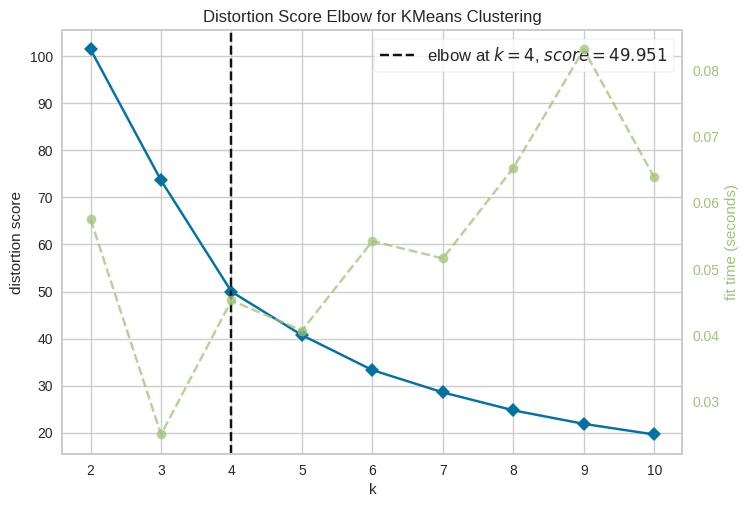

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [24]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer()

# Instantiate the clustering model and visualizer
model = KMeans(random_state=42, n_init=10)  # Added n_init=10 for KMeans
visualizer = KElbowVisualizer(model, k=(2,11)) # Added k range (2, 11)

visualizer.fit(X)    # Fit the data to the visualizer
visualizer.show()   # Finalize and render the figure

In [25]:
# Menggunakan algoritma K-Means Clustering

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)

print("K-Means clustering model trained.")
# Corrected variable name from model_kmeans to kmeans
print(f"Number of clusters: {kmeans.n_clusters}")
# Menambahkan label cluster ke dalam DataFrame
# Corrected variable name from model_kmeans to kmeans
df['Cluster'] = kmeans.labels_

print("DataFrame with cluster labels:")
print(df.head())


K-Means clustering model trained.
Number of clusters: 4
DataFrame with cluster labels:
   TransactionAmount  TransactionDate  TransactionType  Location  Channel  \
0           0.007207              680                1        36        0   
1           0.195940             1178                1        15        0   
2           0.065680             1262                1        23        2   
3           0.096016              818                1        33        2   
5           0.047888              635                1        28        0   

   CustomerAge  CustomerOccupation  TransactionDuration  LoginAttempts  \
0     0.838710                   0             0.244828            0.0   
1     0.806452                   0             0.451724            0.0   
2     0.016129                   3             0.158621            0.0   
3     0.129032                   3             0.051724            0.0   
5     0.000000                   3             0.558621            0.0   

   Ac

Jalankan cell code ini untuk menyimpan model kamu.

In [26]:
# Menyimpan model
import joblib
joblib.dump(kmeans, "model_clustering.h5")

print("Model saved as 'model_clustering.h5'")

Model saved as 'model_clustering.h5'


(Opsional) Membangun Model Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [27]:
# Menghitung dan menampilkan nilai Silhouette Score.

silhouette_avg = silhouette_score(df.drop('Cluster', axis=1), df['Cluster'])

print(f'Silhouette Score: {silhouette_avg}')

Silhouette Score: -0.019768114276099313


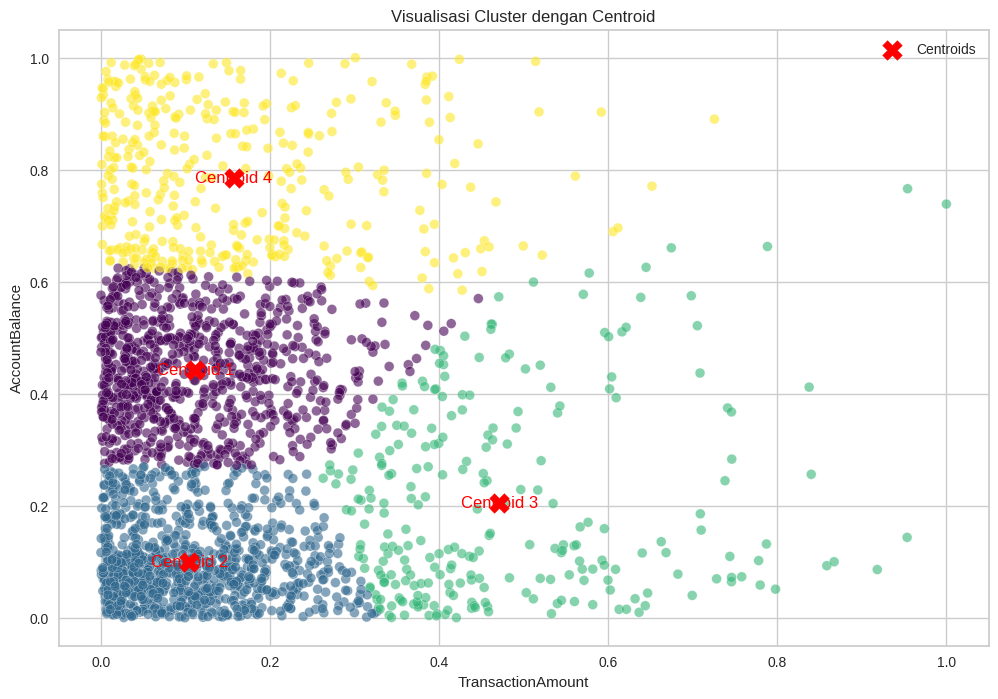

Nilai Centroids:
Centroid 1: Annual Income = 0.11, Spending Score = 0.44
Centroid 2: Annual Income = 0.10, Spending Score = 0.10
Centroid 3: Annual Income = 0.47, Spending Score = 0.21
Centroid 4: Annual Income = 0.16, Spending Score = 0.79


In [28]:
centroids = kmeans.cluster_centers_

# Visualisasi cluster
plt.figure(figsize=(12, 8))

# Plot data
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')

# Plot centroid
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

# Menambahkan label centroid pada plot
for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

# Menambahkan judul dan label
plt.title('Visualisasi Cluster dengan Centroid')
plt.xlabel('TransactionAmount')
plt.ylabel('AccountBalance')
plt.legend()

plt.show()

# Menampilkan nilai centroid
print("Nilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: Annual Income = {centroid[0]:.2f}, Spending Score = {centroid[1]:.2f}")

(Opsional) Membangun Model Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [29]:
# Membangun model menggunakan PCA.

In [30]:
# Simpan model PCA sebagai perbandingan dengan menjalankan cell code ini joblib.dump(model,"PCA_model_clustering.h5")
# joblib.dump(___, "PCA_model_clustering.h5")

# **5. Interpretasi Cluster**

## **a. Interpretasi Hasil Clustering**
1. **Contoh Interpretasi:**
- **Cluster 1: (Nasabah Bertransaksi dan Pendapatan Besar)**:
  - **Rata-rata (mean) Annual Income:** 0.953 (48,260)
  - **Rata-rata (mean) Spending Score:** 0.8 (56.48)
  - **Analisis:** Cluster ini mencakup pelanggan dengan pendapatan tahunan tinggi dan tingkat pengeluaran yang cukup tinggi. Pelanggan dalam cluster ini cenderung memiliki daya beli yang tinggi dan mereka lebih cenderung untuk membelanjakan sebagian besar pendapatan mereka. Sehingga rekomendasi pada kelompok nasabah ini adalah dengan menawarkan produk-produk investasi atau perbankan yang berkualitas tinggi.


In [31]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik dan modus untuk fitur kategorikal.

# Display descriptive statistics for each cluster
for cluster in df['Cluster'].unique():
    print(f"Cluster {cluster}:")
    cluster_data = df[df['Cluster'] == cluster]

    # Descriptive statistics for numerical features (mean, min, max)
    print("\nNumerical Feature Statistics:")
    numerical_cols = cluster_data.select_dtypes(include=np.number).drop('Cluster', axis=1).columns
    if not numerical_cols.empty:
        print(cluster_data[numerical_cols].agg(['mean', 'min', 'max']).T)

for cluster in df['Cluster'].unique():
    # Mode for categorical features (using the encoded data for simplicity)
    print("\nCategorical Feature Statistics (Mode):")
    categorical_cols = cluster_data.select_dtypes(include='int64').columns
    if not categorical_cols.empty:
         # Need to decode the categorical features back to their original values if possible for better interpretation
         # For simplicity here, we'll show the mode of the encoded values
         print(cluster_data[categorical_cols].mode().T)

    print("-" * 50)



Cluster 0:

Numerical Feature Statistics:
                                mean       min          max
TransactionAmount           0.111958  0.000031     0.446434
TransactionDate          1255.687124  2.000000  2485.000000
TransactionType             0.796631  0.000000     2.000000
Location                   20.848375  0.000000    43.000000
Channel                     1.028881  0.000000     3.000000
CustomerAge                 0.539517  0.000000     1.000000
CustomerOccupation          1.237064  0.000000     4.000000
TransactionDuration         0.375833  0.000000     0.996552
LoginAttempts               0.028881  0.000000     1.000000
AccountBalance              0.441581  0.272195     0.624083
PreviousTransactionDate   179.095066  0.000000   360.000000
Cluster 3:

Numerical Feature Statistics:
                                mean        min         max
TransactionAmount           0.156363   0.000459     0.72558
TransactionDate          1254.360434  15.000000  2485.00000
TransactionType 

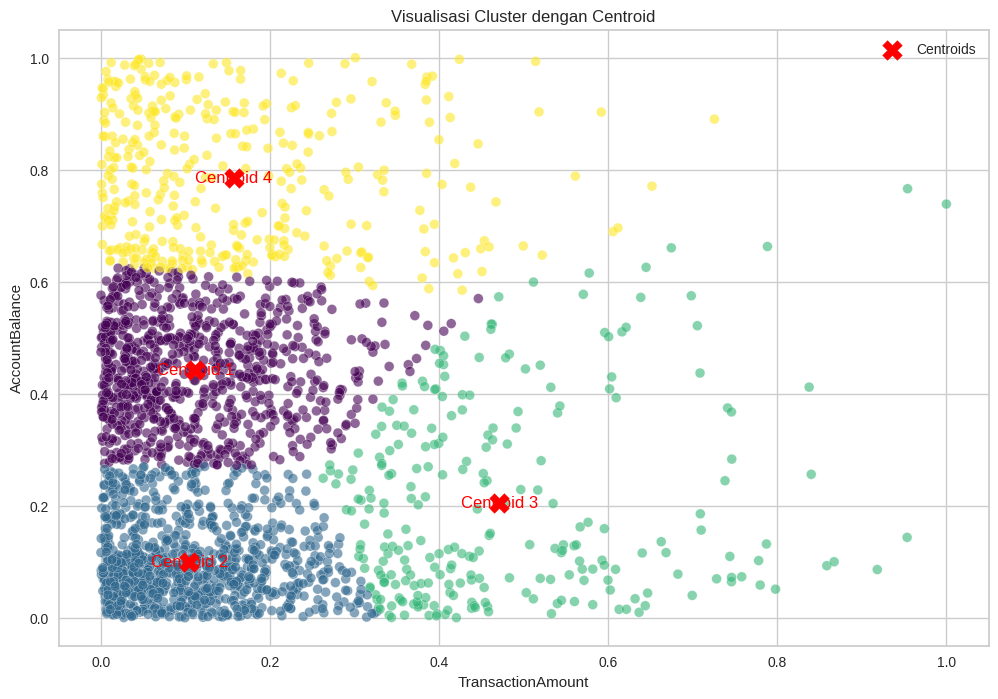

Nilai Centroids:
Centroid 1: Annual Income = 0.11, Spending Score = 0.44
Centroid 2: Annual Income = 0.10, Spending Score = 0.10
Centroid 3: Annual Income = 0.47, Spending Score = 0.21
Centroid 4: Annual Income = 0.16, Spending Score = 0.79


In [32]:
centroids = kmeans.cluster_centers_

# Visualisasi cluster
plt.figure(figsize=(12, 8))

# Plot data
plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, cmap='viridis', s=50, alpha=0.6, edgecolors='w', marker='o')

# Plot centroid
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, marker='X', label='Centroids')

# Menambahkan label centroid pada plot
for i, centroid in enumerate(centroids):
    plt.text(centroid[0], centroid[1], f'Centroid {i+1}', color='red', fontsize=12, ha='center', va='center')

# Menambahkan judul dan label
plt.title('Visualisasi Cluster dengan Centroid')
plt.xlabel('TransactionAmount')
plt.ylabel('AccountBalance')
plt.legend()

plt.show()

# Menampilkan nilai centroid
print("Nilai Centroids:")
for i, centroid in enumerate(centroids):
    print(f"Centroid {i+1}: Annual Income = {centroid[0]:.2f}, Spending Score = {centroid[1]:.2f}")

## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya.
1. **Cluster 1: (Medium Account Balance, Low Transaction Amount)**:
  - **Transaction (mean):** 0.111958
  - **AccountBalance (mean):** 0.441581
  - **Analisis:** Cluster ini berisikan customer dengan account balance di rentang menengah dengan angka transaksi yang terbilang kecil.

2. **Cluster 2: (Low Account Balance, Low Transaction Amount)**:
  - **Transaction (mean):** 0.104706
  - **AccountBalance (mean):** 0.100212
  - **Analisis:** Cluster ini berisikan customer dengan account balance yang terbilang kecil dengan angka transaksi yang juga kecil.

3. **Cluster 3: (Low to Medium Account Balance, High Transaction Amount)**:
  - **Transaction (mean):** 0.471360
  - **AccountBalance (mean):** 0.205642
  - **Analisis:** Cluster ini berisikan customer dengan account balance dari kecil ke menengah dengan angka transaksi yang tinggi.

4. **Cluster 4: (High Account Balance, Low to High Transaction Amount)**:
  - **Transaction (mean):** 0.156363
  - **AccountBalance (mean):** 0.785096
  - **Analisis:** Cluster ini berisikan customer dengan account balance yang tinggi dengan angka transaksi angka transaksi pada tiap category

# **6. Mengeksport Data**

1. Simpan nama kolom hasil clustering dengan nama `Target`.
2. Simpan hasilnya ke dalam file CSV menggunakan function `to_csv()`.

In [33]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df = df.rename(columns={'Cluster': 'Target'})
print(df.head())


   TransactionAmount  TransactionDate  TransactionType  Location  Channel  \
0           0.007207              680                1        36        0   
1           0.195940             1178                1        15        0   
2           0.065680             1262                1        23        2   
3           0.096016              818                1        33        2   
5           0.047888              635                1        28        0   

   CustomerAge  CustomerOccupation  TransactionDuration  LoginAttempts  \
0     0.838710                   0             0.244828            0.0   
1     0.806452                   0             0.451724            0.0   
2     0.016129                   3             0.158621            0.0   
3     0.129032                   3             0.051724            0.0   
5     0.000000                   3             0.558621            0.0   

   AccountBalance  PreviousTransactionDate  Target  
0        0.336832                      

In [34]:
# Simpan Data
df.to_csv('data_clustering.csv', index=False)

(Opsional) Interpretasi Hasil Clustering [Skilled]

**Biarkan kosong jika tidak menerapkan kriteria skilled**

In [35]:
df[numerical_features] = scaler.inverse_transform(df[numerical_features])
print("Numerical features after inverse transformation:")
print(df[numerical_features].head())


Numerical features after inverse transformation:
   TransactionAmount  CustomerAge  TransactionDuration  LoginAttempts  \
0              14.09         70.0                 81.0            1.0   
1             376.24         68.0                141.0            1.0   
2             126.29         19.0                 56.0            1.0   
3             184.50         26.0                 25.0            1.0   
5              92.15         18.0                172.0            1.0   

   AccountBalance  
0         5112.21  
1        13758.91  
2         1122.35  
3         8569.06  
5          781.68  


In [36]:
df.describe()

,TransactionAmount,TransactionDate,TransactionType,Location,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,Target
count,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000,2398.000000
mean,297.532219,1256.404921,0.788574,21.383653,1.013344,44.618015,1.532110,119.481234,1.120100,5089.861643,180.984987,1.069641
std,291.459657,726.716182,0.437979,12.417622,0.831075,17.836252,1.153802,70.285895,0.588235,3901.212086,103.757245,1.032507
min,0.260000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,10.000000,1.000000,101.250000,0.000000,0.000000
25%,82.050000,626.250000,1.000000,11.000000,0.000000,27.000000,0.000000,63.000000,1.000000,1489.072500,92.000000,0.000000
50%,212.925000,1254.500000,1.000000,21.000000,1.000000,45.000000,2.000000,112.000000,1.000000,4683.440000,181.000000,1.000000
75%,411.345000,1884.750000,1.000000,32.000000,2.000000,59.000000,3.000000,162.000000,1.000000,7655.992500,271.750000,2.000000
max,1919.110000,2485.000000,2.000000,43.000000,3.000000,80.000000,4.000000,300.000000,5.000000,14977.990000,360.000000,3.000000


## Menjelaskan karakteristik tiap cluster berdasarkan rentangnya setelah inverse.
1. **Cluster 1: (Medium Account Balance, Low Transaction Amount)**:
  - **AccountBalance (mean):** 6670.54
  - **Transaction (mean):** 215.08
  - **Analisis:** Cluster ini berisikan customer dengan account balance di rentang menengah dengan angka transaksi yang terbilang kecil.

2. **Cluster 2: (Low Account Balance, Low Transaction Amount)**:
  - **AccountBalance (mean):** 1592.07
  - **Transaction (mean):** 201.17
  - **Analisis:** Cluster ini berisikan customer dengan account balance yang terbilang kecil dengan angka transaksi yang juga kecil.

3. **Cluster 3: (Low to Medium Account Balance, High Transaction Amount)**:
  - **AccountBalance (mean):** 3160.53
  - **Transaction (mean):** 904.73
  - **Analisis:** Cluster ini berisikan customer dengan account balance dari kecil ke menengah dengan angka transaksi yang tinggi.

4. **Cluster 4: (High Account Balance, Low-High Transaction Amount)**:
  - **AccountBalance (mean):** 11780.92
  - **Transaction (mean):** 300.29
  - **Analisis:** Cluster ini berisikan customer dengan account balance yang tinggi dengan angka transaksi pada tiap category

(Opsional) Interpretasi Hasil Clustering [Advanced]

**Biarkan kosong jika tidak menerapkan kriteria advanced**

In [37]:
# Mengintegrasikan kembali data yang telah di-inverse dengan hasil cluster.

# Display descriptive statistics for each cluster
for cluster in df['Target'].unique():
    print(f"Target {cluster}:")
    cluster_data = df[df['Target'] == cluster]

    # Descriptive statistics for numerical features (mean, min, max)
    print("\nNumerical Feature Statistics:")
    numerical_cols = cluster_data.select_dtypes(include=np.number).drop('Target', axis=1).columns
    if not numerical_cols.empty:
        print(cluster_data[numerical_cols].agg(['mean', 'min', 'max']).T)

for cluster in df['Target'].unique():
    # Mode for categorical features (using the encoded data for simplicity)
    print("\nCategorical Feature Statistics (Mode):")
    categorical_cols = cluster_data.select_dtypes(include='int64').columns
    if not categorical_cols.empty:
         # Need to decode the categorical features back to their original values if possible for better interpretation
         # For simplicity here, we'll show the mode of the encoded values
         print(cluster_data[categorical_cols].mode().T)

    print("-" * 50)


Target 0:

Numerical Feature Statistics:
                                mean      min      max
TransactionAmount         215.089904     0.32   856.90
TransactionDate          1255.687124     2.00  2485.00
TransactionType             0.796631     0.00     2.00
Location                   20.848375     0.00    43.00
Channel                     1.028881     0.00     3.00
CustomerAge                51.450060    18.00    80.00
CustomerOccupation          1.237064     0.00     4.00
TransactionDuration       118.991576    10.00   299.00
LoginAttempts               1.115523     1.00     5.00
AccountBalance           6670.540866  4150.63  9385.57
PreviousTransactionDate   179.095066     0.00   360.00
Target 3:

Numerical Feature Statistics:
                                 mean      min       max
TransactionAmount          300.297127     1.14   1392.54
TransactionDate           1254.360434    15.00   2485.00
TransactionType              0.772358     0.00      2.00
Location                    21

In [38]:
# Simpan Data
df.to_csv('data_clustering_inverse.csv', index=False)